## Import Dependencies

In [1]:
from preprocessing_container.data_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Optional, List
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## Load Data and Preprocess

In [45]:
TRIMS = ["down", "up", "rnti_count", "rb_down", "rb_up"]
TIME_FEATURES = ["min_of_day", "day_of_week", "day_of_year"]
TIME_FEATURES = [f"{feature}_sin" for feature in TIME_FEATURES] + [f"{feature}_cos" for feature in TIME_FEATURES]

df = read_data(r"./dataset/full_dataset.csv", "PobleSec")
df = handle_nans(df)
df = df[TRIMS] # reduce feature set for testing
df, scaler = scale_data(df)
df = time_to_feature(df)

df_eval = read_data(r"./dataset/PobleSec_test.csv")
df_eval = handle_nans(df_eval)
df_eval = df_eval[TRIMS]
df_eval, _ = scale_data(df_eval, scale=scaler)
df_eval = time_to_feature(df_eval)

## Define Model

In [46]:
class LSTM(nn.Module):
    def __init__(self, n_endo_features, n_exo_features, hidden_size, output_size, num_layers=1):
        super(LSTM, self).__init__()
        self.n_features = n_endo_features + n_exo_features
        self.n_endo_features = n_endo_features
        self.n_exo_features = n_exo_features
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(self.n_features, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size * n_endo_features)
    
    def forward(self, x):
        """
        Defines the forward pass of the model.
        
        Args:
            x (torch.Tensor): The input tensor of shape (batch_size, sequence_length, n_features).
        
        Returns:
            torch.Tensor: The output tensor from the model.
        """
        # --- Initialize Hidden and Cell States ---
        # The LSTM needs initial hidden and cell states. If not provided, they default to zeros.
        # The shape is (num_layers, batch_size, hidden_size).
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # --- LSTM Forward Pass ---
        # The LSTM returns the output of the entire sequence and the final hidden and cell states.
        # out shape: (batch_size, sequence_length, hidden_size)
        # hn shape: (num_layers, batch_size, hidden_size)
        # cn shape: (num_layers, batch_size, hidden_size)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # --- Fully-Connected Layer ---
        # We are interested in the output of the last time step for many sequence tasks
        # (e.g., classification, next value prediction).
        # out[:, -1, :] selects the output of the last element in the sequence for each batch.
        # Shape of out[:, -1, :]: (batch_size, hidden_size)
        out = self.fc(out[:, -1, :])
        
        # Reshape the output to be (batch_size, output_seq_len, output_features)
        # This matches the shape of our target tensor.
        out = out.view(x.size(0), self.output_size, self.n_endo_features)
        
        return out

## Convert from Dataframe to Numpy array input sequences

In [47]:
def window_data(df: pd.DataFrame, exo_features: Optional[List[str]] = None, input_len: int = 10, output_len: int = 1) -> tuple:
    """
    Splits the DataFrame into input features and target variables.
    """
    n_rows = df.shape[0]

    if exo_features is not None:
        x_df = df.copy()
        y_df = df.drop(columns=exo_features)
    else:
        x_df = df.copy()
        y_df = df
    
    x = np.zeros((n_rows, input_len, x_df.shape[1]), dtype=np.float32)
    y = np.zeros((n_rows, output_len, y_df.shape[1]), dtype=np.float32)

    for row in range(n_rows - input_len - output_len + 1):
        x[row, :input_len, :] = x_df.iloc[row:row+input_len, :].values
        y[row, :output_len, :] = y_df.iloc[row:row+output_len, :].values
    
    return x, y

X, y = window_data(df, TIME_FEATURES)
print(f"Shape of df: {df.shape}")
print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (output sequences): {y.shape}")

Shape of df: (15927, 11)
Shape of X (input sequences): (15927, 10, 11)
Shape of y (output sequences): (15927, 1, 5)


## Data Split

In [48]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## Convert Numpy arrays to Torch tensors and then to data loaders

In [49]:
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train Tensor Shape: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"Test Tensor Shape: {X_test_tensor.shape}, {y_test_tensor.shape}")

Train Tensor Shape: torch.Size([12741, 10, 11]), torch.Size([12741, 1, 5])
Test Tensor Shape: torch.Size([3186, 10, 11]), torch.Size([3186, 1, 5])


## Instantiate and train the model

In [ ]:
# Hyperparameters
N_ENDO_FEATURES = df.shape[1] - len(TIME_FEATURES)  # Number of features in the input data
N_EXO_FEATURES = len(TIME_FEATURES)  # Number of exogenous features
OUTPUT_SEQ_LEN = 1
HIDDEN_SIZE = 128
NUM_LAYERS = 4
LEARNING_RATE = 0.001
NUM_EPOCHS = 40

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = LSTM(
    n_endo_features=N_ENDO_FEATURES, 
    n_exo_features=N_EXO_FEATURES, 
    hidden_size=HIDDEN_SIZE, 
    num_layers=NUM_LAYERS, 
    output_size=OUTPUT_SEQ_LEN
).to(device)

criterion = nn.MSELoss()  # Mean Squared Error is a good choice for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

Using device: cpu


## Training Loop

In [63]:
loss_history = []
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {epoch_loss:.6f}")

Epoch [1/40], Loss: 0.354154
Epoch [2/40], Loss: 0.204401
Epoch [3/40], Loss: 0.150641
Epoch [4/40], Loss: 0.146845
Epoch [5/40], Loss: 0.147693
Epoch [6/40], Loss: 0.135559
Epoch [7/40], Loss: 0.143360
Epoch [8/40], Loss: 0.142687
Epoch [9/40], Loss: 0.123448
Epoch [10/40], Loss: 0.136543
Epoch [11/40], Loss: 0.237330
Epoch [12/40], Loss: 0.238063
Epoch [13/40], Loss: 0.180612
Epoch [14/40], Loss: 0.124150
Epoch [15/40], Loss: 0.104596
Epoch [16/40], Loss: 0.064716
Epoch [17/40], Loss: 0.041598
Epoch [18/40], Loss: 0.034942
Epoch [19/40], Loss: 0.038350
Epoch [20/40], Loss: 0.032399
Epoch [21/40], Loss: 0.028113
Epoch [22/40], Loss: 0.026520
Epoch [23/40], Loss: 0.022247
Epoch [24/40], Loss: 0.023654
Epoch [25/40], Loss: 0.022945
Epoch [26/40], Loss: 0.030115
Epoch [27/40], Loss: 0.026872
Epoch [28/40], Loss: 0.033657
Epoch [29/40], Loss: 0.032939
Epoch [30/40], Loss: 0.022274
Epoch [31/40], Loss: 0.019209
Epoch [32/40], Loss: 0.016578
Epoch [33/40], Loss: 0.018426
Epoch [34/40], Loss

## Plot Training Loss

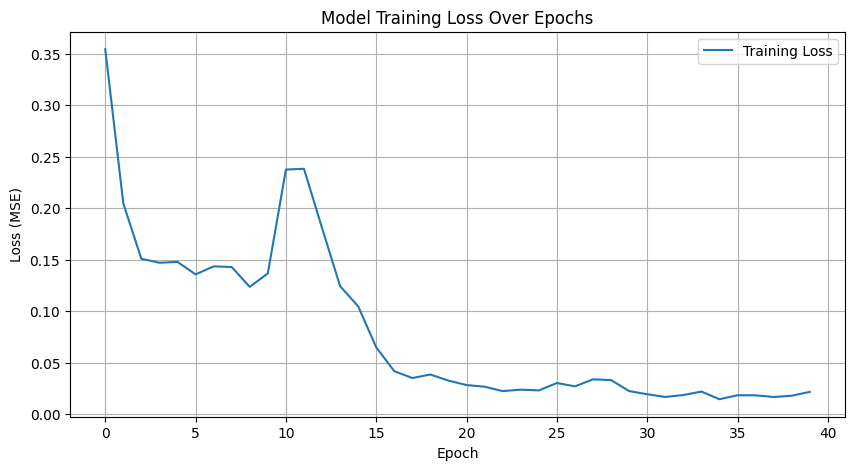

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Prepare Evaluation Data

In [65]:
X_eval, y_eval = window_data(df_eval, TIME_FEATURES)
X_eval_tensor = torch.from_numpy(X_eval).float()
y_eval_tensor = torch.from_numpy(y_eval).float()
eval_dataset = TensorDataset(X_eval_tensor, y_eval_tensor)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

## Infer via Recursive Forecast

In [79]:
model.eval()
SAMPLE_IDX = 0
INFERENCE_LENGTH = 720


# Determine the sampling frequency from the data
timedelta = check_uniform(df_eval)

# How much real data is available for the forecast window
remaining_real_data = X_eval.shape[0] - SAMPLE_IDX
available_future_steps = min(remaining_real_data, INFERENCE_LENGTH)
num_extension_steps = INFERENCE_LENGTH - available_future_steps

df_predictions = pd.DataFrame(
    index=pd.date_range(
        start=df_eval.index[SAMPLE_IDX],
        periods=INFERENCE_LENGTH,
        freq=timedelta
    ),
    columns=df_eval.columns
)

FEATURES = df_eval.columns.difference(TIME_FEATURES, sort=False).tolist()

df_predictions = time_to_feature(df_predictions)

current_sequence = X_eval_tensor[SAMPLE_IDX].unsqueeze(0).to(device)

with torch.no_grad():
    step = 0
    while step < INFERENCE_LENGTH:
        multi_step_pred = model(current_sequence)   # Shape: (1, OUTPUT_SEQ_LEN, num_features)
        remaining_steps = INFERENCE_LENGTH - step   # Decide how many of the predicted steps to use in this loop
        steps_to_use = min(OUTPUT_SEQ_LEN, remaining_steps)

        for i in range(steps_to_use):
            absolute_step = step + i
            next_step = absolute_step + 1
            if absolute_step >= INFERENCE_LENGTH:
                break

            # Get prediction and store it
            current_pred = multi_step_pred[:, i, :].cpu().numpy().flatten()
            df_predictions.loc[df_predictions.index[absolute_step], FEATURES] = current_pred

            # Update sequence
            if next_step <= available_future_steps:
                current_sequence = X_eval_tensor[SAMPLE_IDX + next_step].unsqueeze(0).to(device)
            else:
                extension_idx = next_step - available_future_steps
                print("CALLED EXTENSION MODE")

                if extension_idx < df_predictions.shape[0]:
                    # Extract future exogenous data from df_extension
                    extension_row = df_predictions.iloc[[extension_idx]][TIME_FEATURES]
                    numpy_extension, _ = window_data(
                        extension_row,
                        TIME_FEATURES,
                        input_len=1, output_len=1
                    )
                    exog_tensor = torch.from_numpy(numpy_extension).float()
                    pred_tensor = torch.tensor(current_pred).view(1, 1, -1)
                    print(f"Current Sequence shape: {current_sequence.shape}")
                    print(f"Prediction Tensor shape: {pred_tensor.shape}")
                    print(f"Exogenous Tensor shape: {exog_tensor.shape}")

                    current_pred = torch.cat((pred_tensor, exog_tensor), dim=-1)
                    current_sequence = torch.cat((current_sequence[:, 1:, :], current_pred), dim=1)
                else:
                    print(f"[Warning] df_extension exhausted at index {extension_idx}")
                    break

        step += steps_to_use


df_predictions = df_predictions.drop(columns=TIME_FEATURES)
df = pd.DataFrame(
    scaler.inverse_transform(df_predictions),
    index=df_predictions.index,
    columns=df_predictions.columns
)

print(f"Inference completed:")
print(f"- Used actual future values for first {min(available_future_steps, INFERENCE_LENGTH)} steps")
if INFERENCE_LENGTH > available_future_steps:
    print(f"- Switched to recursive mode after step {available_future_steps}")
print(f"- Model predicts {OUTPUT_SEQ_LEN} step(s) at a time")
print(f"- Total predictions generated: {df.shape[0]}")

# Get the corresponding actual future values from the test set for comparison
# Make sure we only get as many actual values as we have predictions
actual_length = min(len(y_eval) - SAMPLE_IDX, df.shape[0])
actual_values_scaled = y_eval[SAMPLE_IDX : SAMPLE_IDX + actual_length]

# Reshape the actual values to match prediction format
actual_values_scaled = actual_values_scaled.reshape(-1, N_ENDO_FEATURES)

# Unscale the actual values to their original representation
actual_values_unscaled = scaler.inverse_transform(actual_values_scaled)

Inference completed:
- Used actual future values for first 720 steps
- Model predicts 1 step(s) at a time
- Total predictions generated: 720


## Visualize the Inference

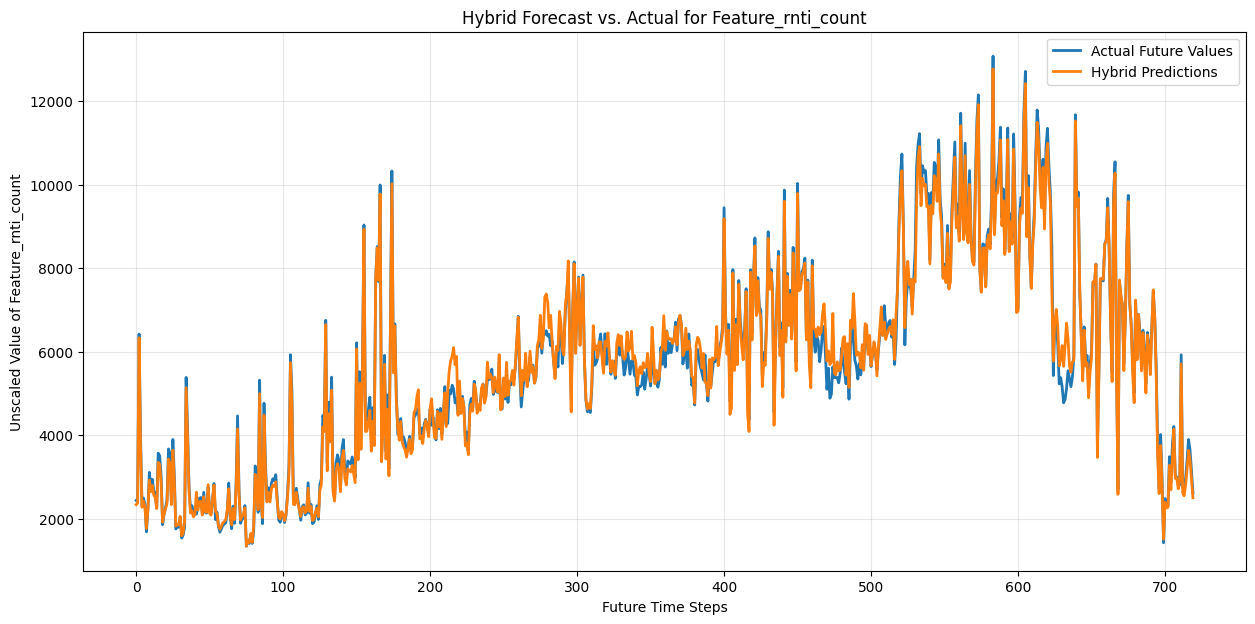

In [84]:
plt.figure(figsize=(15, 7))

# Select which feature to plot (0 for first feature, etc.)
feature_to_plot = "rnti_count"
feature_name = f"Feature_{feature_to_plot}"  # Adjust this to match your actual feature names
x_axis = np.arange(len(actual_values_unscaled))  # Use actual length, not INFERENCE_LENGTH

# Plot the unscaled data for a meaningful comparison
column_index = df.columns.get_loc(feature_to_plot)
plt.plot(x_axis, actual_values_unscaled[:, column_index], '-', label='Actual Future Values', linewidth=2)
plt.plot(x_axis, df[feature_to_plot], '-', label='Hybrid Predictions', linewidth=2)

plt.title(f'Hybrid Forecast vs. Actual for {feature_name}')
plt.xlabel('Future Time Steps')
plt.ylabel(f'Unscaled Value of {feature_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Additional Analysis: Show where method switched from windowed to recursive ---
if len(actual_values_unscaled) > available_future_steps:
    plt.figure(figsize=(15, 7))
    
    # Plot windowed phase
    windowed_x = np.arange(available_future_steps)
    plt.plot(windowed_x, actual_values_unscaled[:available_future_steps, feature_to_plot], 
             '-', label='Actual (Windowed Phase)', linewidth=2, color='blue')
    plt.plot(windowed_x, df[:available_future_steps, feature_to_plot], 
             '--', label='Hybrid Predictions (Windowed)', linewidth=2, color='orange')
    
    # Plot recursive phase
    recursive_x = np.arange(available_future_steps, len(actual_values_unscaled))
    plt.plot(recursive_x, actual_values_unscaled[available_future_steps:, feature_to_plot], 
             '-', label='Actual (Recursive Phase)', linewidth=2, color='green')
    plt.plot(recursive_x, df[available_future_steps:, feature_to_plot], 
             '--', label='Hybrid Predictions (Recursive)', linewidth=2, color='red')
    
    # Add vertical line to show transition
    plt.axvline(x=available_future_steps, color='black', linestyle=':', alpha=0.7, 
                label=f'Transition to Recursive (Step {available_future_steps})')
    
    plt.title(f'Hybrid Method: Windowed vs Recursive Phases for {feature_name}')
    plt.xlabel('Future Time Steps')
    plt.ylabel(f'Unscaled Value of {feature_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
